In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from seaborn import color_palette
import h5py, matplotlib, os

from deep_lss.utils import emulator, abc
from msfm.utils import prior, files, parameters

from emcee import EnsembleSampler
from trianglechain import TriangleChain

# setup
matplotlib.rcParams.update({'font.size': 14})
np.set_printoptions(precision=3)
print(tf.config.list_physical_devices())
conf = files.load_config()

23-05-25 08:11:08     utils.py INF   Loaded the config 
23-05-25 08:11:08   kernels.py INF   Setting the minimum value of the kernel function to 1e-42 for the mpmath library 
23-05-25 08:11:08    scales.py INF   Setting up healpy to run on 256 CPUs 
[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU'), PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


# load the summaries

In [2]:
def load_preds(base_dir, model_dir, n_steps=None):
    out_dir = os.path.join(base_dir, model_dir)
    
    if n_steps is None:
        preds_file = os.path.join(out_dir, f"preds.h5")
    else:
        preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")

    with h5py.File(preds_file, "r") as f:
        # fiducial
        fidu_preds = f["fiducial/preds"][:]
        print(f"fidu_preds =        {fidu_preds.shape}")

        # grid
        grid_preds = f["grid/preds"][:]
        grid_cosmos = f["grid/cosmos"][:]
        print(f"grid_preds.shape =  {grid_preds.shape}")
        print(f"grid_cosmos.shape = {grid_cosmos.shape}")
        print(f"\nsingle grid pred example = {grid_preds[0,0]}")

    return fidu_preds, grid_preds, grid_cosmos

### individual experiments

In [3]:
base_dir = "/pscratch/sd/a/athomsen/run_files/v3/"

In [4]:
# # old, lensing only

# preds_file = "/pscratch/sd/a/athomsen/run_files/2023-03-13_06-27-46_resnet_small/preds.h5"

# fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

# # only select unique values of Om and s8
# grid_cosmos = grid_cosmos[:,0,[2,4]]

# print(grid_cosmos.shape)

# params = ["Om", "s8"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$']
# fiducial = {"Om": 0.26, "s8": 0.84}

In [5]:
# # probably overfit
# model_dir = "2023-05-15_07-04-57_resnet_vanilla"

# fidu_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir)

# params = ["Om", "s8", "bg", "n_bg"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

In [27]:
# clustering only, regular evaluation
model_dir = "2023-05-24_05-18-42_resnet_vanilla"
n_steps = 20000

fidu_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

params = ["Om", "s8", "bg", "n_bg"]
n_params = len(params)
param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$b_g$', r'$\eta_{b_g}$']
fiducial = {"Om": 0.26, "s8": 0.84, "bg": 1.5, "n_bg": 0.5}

fidu_preds =        (800, 4)
grid_preds.shape =  (2499, 16, 4)
grid_cosmos.shape = (2499, 4)

single grid pred example = [ 0.422 -0.318 -0.149 -0.793]


In [28]:
# # lensing only, regular evaluation
# model_dir = "2023-05-24_05-26-55_resnet_vanilla"
# n_steps = 15000

# fidu_preds, grid_preds, grid_cosmos = load_preds(base_dir, model_dir, n_steps)

# params = ["Om", "s8", "Aia", "n_Aia"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$', r'$A_{IA}$', r'$\eta_{A_{IA}}$']
# fiducial = {"Om": 0.26, "s8": 0.84, "Aia": 0.5, "n_Aia": 1.5}

In [29]:
# # lensing only, regular evaluation, reduced parameters
# model_dir = "2023-05-24_06-39-40_resnet_vanilla"

# n_steps = 20000
# out_dir = os.path.join(base_dir, model_dir)
# preds_file = os.path.join(out_dir, f"preds_{n_steps}.h5")

# fidu_preds, grid_preds, grid_cosmos = load_preds(preds_file)

# params = ["Om", "s8"]
# n_params = len(params)
# param_labels = [r'$\Omega_m$', r'$\sigma_8$']
# fiducial = {"Om": 0.26, "s8": 0.84}

### plot the summaries

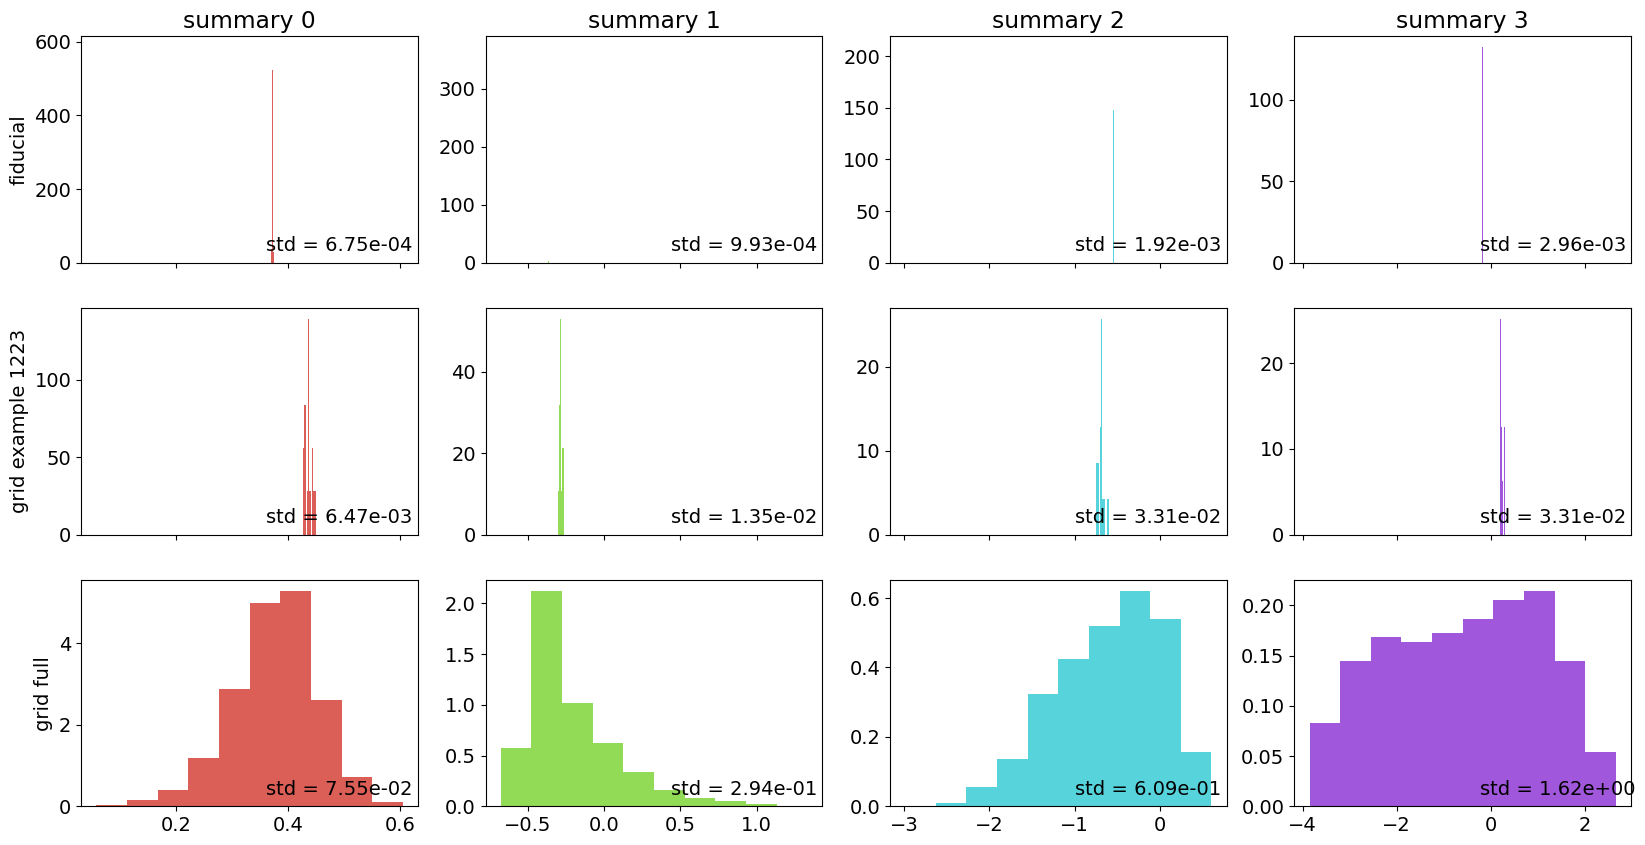

In [30]:
colors = color_palette("hls", n_params)
n_bins = 10

fig, ax = plt.subplots(nrows=3, ncols=n_params, figsize=(20,10), sharex="col")

ax[0,0].set(ylabel="fiducial")
for i in range(n_params):
    preds = fidu_preds[:,i]
    
    ax[0,i].hist(preds, density=True, color=colors[i], bins=n_bins)
    ax[0,i].set(title=f"summary {i}")
    ax[0,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[0,i].transAxes)

i_example = np.random.randint(grid_preds.shape[0])

ax[1,0].set(ylabel=f"grid example {i_example}")
for i in range(n_params):
    preds = grid_preds[i_example,:,i]
    
    ax[1,i].hist(preds, density=True, color=colors[i], bins=n_bins)
    ax[1,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[1,i].transAxes)

ax[2,0].set(ylabel="grid full")
for i in range(n_params):
    preds = grid_preds[:,:,i].flatten()
    
    ax[2,i].hist(preds, density=True, color=colors[i], bins=n_bins)
    ax[2,i].text(0.55, 0.05, f"std = {np.std(preds):.2e}", transform=ax[2,i].transAxes)


# Estimate the ABC posterior

### define the observation

In [31]:
# TODO make a distinction between validation and fiducial prediction
obs_pred = np.median(fidu_preds, axis=0)

### estimate the Fisher matrix

In [32]:
# from sklearn.decomposition import PCA

# # fit
# pca = PCA(whiten=False)
# pca.fit(fidu_preds)

# # transform
# obs_pred = np.squeeze(pca.transform(obs_pred[np.newaxis,:]))
# fidu_preds = pca.transform(fidu_preds)

# original_shape = grid_preds.shape
# grid_preds = grid_preds.reshape(-1, grid_preds.shape[-1])
# grid_preds = pca.transform(grid_preds)
# grid_preds = grid_preds.reshape(original_shape)

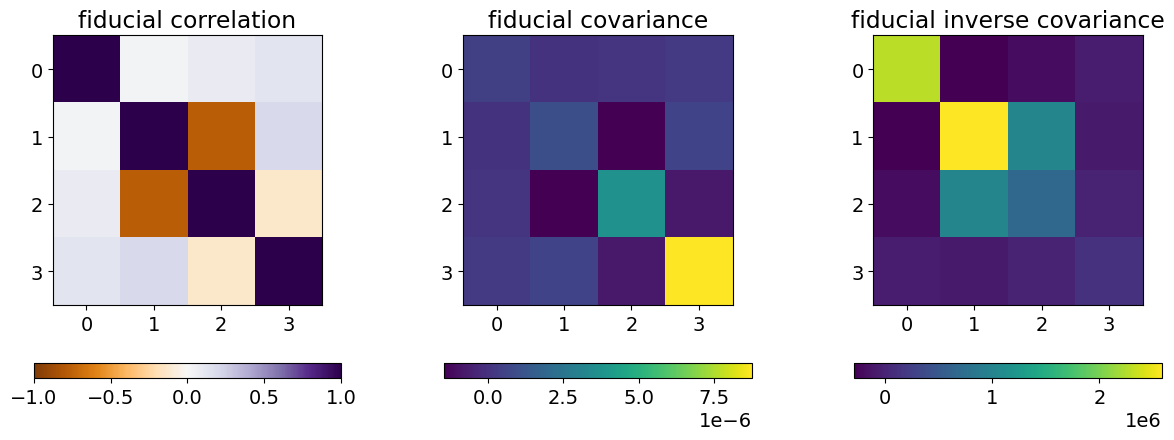

In [35]:
# get an approximation to the Fisher  matrix
fid_cov = np.cov(fidu_preds, rowvar=False)
fid_inv_cov = np.linalg.inv(fid_cov)

# plot as a sanity check
fig, ax = plt.subplots(ncols=3, figsize=(15,5))

# correlation
im = ax[0].imshow(np.corrcoef(fidu_preds, rowvar=False), cmap="PuOr", vmin=-1, vmax=1)
fig.colorbar(im, ax=ax[0], orientation="horizontal", shrink=0.9)
ax[0].set(title=f"fiducial correlation")

# covariance
im = ax[1].imshow(fid_cov, cmap="viridis")
fig.colorbar(im, ax=ax[1], orientation="horizontal", shrink=0.9)
ax[1].set(title=f"fiducial covariance")

# inverse covariance
im = ax[2].imshow(fid_inv_cov, cmap="viridis")
fig.colorbar(im, ax=ax[2], orientation="horizontal", shrink=0.9)
ax[2].set(title=f"fiducial inverse covariance")

# cosmetics
for current_ax in ax:
    current_ax.set_xticks(np.arange(len(params)))
    current_ax.set_xticklabels(np.arange(fid_cov.shape[0]))

    current_ax.set_yticks(np.arange(len(params)))
    current_ax.set_xticklabels(np.arange(fid_cov.shape[0]))


### ABC posterior

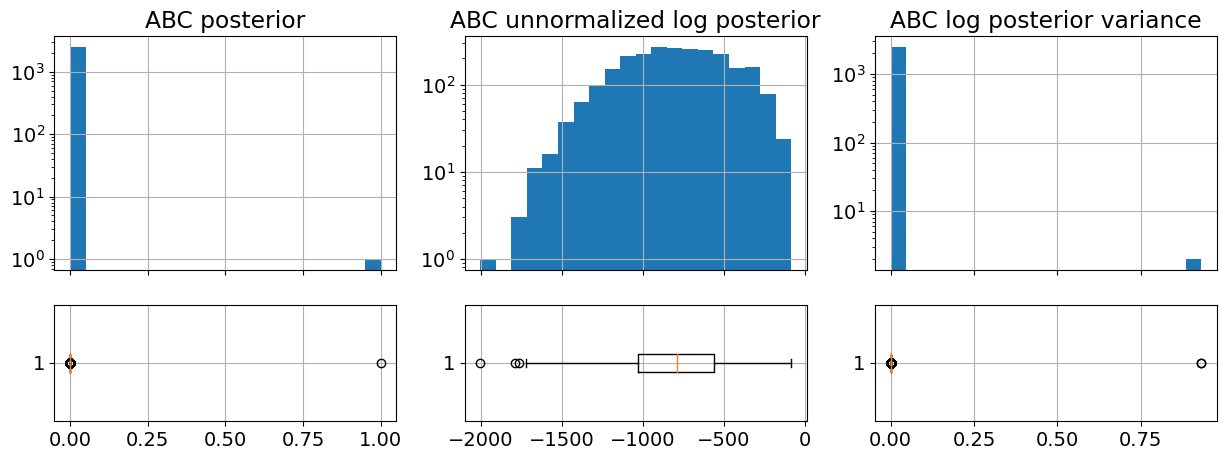

In [34]:
# kernel params
kernel = "sigmoid"
scale = 1.0

# Estimate the posterior and its uncertainties like in the paper
Y_init, abc_posterior = abc.estimate_grid_posterior(
    grid_preds=grid_preds, 
    fid_fisher=fid_inv_cov, 
    obs_pred=obs_pred, 
    scale=scale, 
    kernel=kernel
)

# check posterior
assert np.isclose(np.sum(abc_posterior), 1.0)

fig, ax = plt.subplots(nrows=2, ncols=3, sharex="col", figsize=(15,5), height_ratios=[2,1])

# posterior
ax[0,0].hist(abc_posterior, log=True, bins=20)
ax[0,0].set(title="ABC posterior")

ax[1,0].boxplot(abc_posterior, vert=False)

# log posterior
ax[0,1].hist(Y_init[:,0], log=True, bins=20)
ax[0,1].set(title="ABC unnormalized log posterior")

ax[1,1].boxplot(Y_init[:,0], vert=False)

# log posterior variance
ax[0,2].hist(Y_init[:,1], log=True, bins=20)
ax[0,2].set(title="ABC log posterior variance")

ax[1,2].boxplot(Y_init[:,1], vert=False)

# cosmetics
for i in range(2):
    for j in range(3):
        ax[i,j].grid(True)

In [14]:
Om = grid_cosmos[:,0]
s8 = grid_cosmos[:,1]

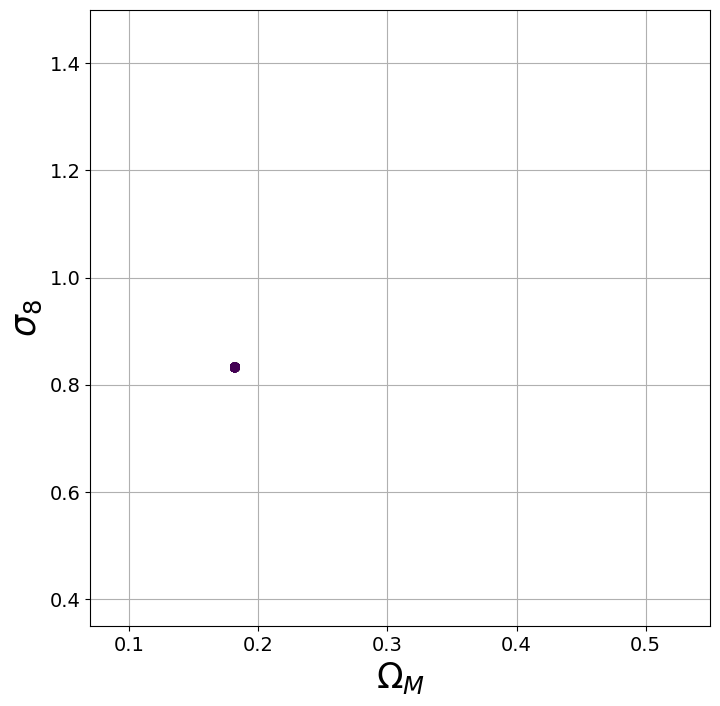

In [15]:
# select a random subset
np.random.seed(11)
probable_indices = np.random.choice(np.arange(len(abc_posterior)), 100, p=abc_posterior, replace=True)

Om_p, s8_p, post_p = Om[probable_indices], s8[probable_indices], abc_posterior[probable_indices],

fig, ax = plt.subplots(figsize=(8,8))
ax.scatter(Om_p, s8_p, c=np.log(post_p))
ax.set(xlim=(0.07, 0.55), ylim=(0.35, 1.5))
ax.set_xlabel("$\Omega_M$", fontsize=25)
ax.set_ylabel("$\sigma_8$", fontsize=25)
ax.grid(True)

# Fit the emulator

In [ ]:
X_init = grid_cosmos

In [20]:
n_grid_points = 1000
indices = np.random.choice(np.arange(X_init.shape[0]), n_grid_points, replace=False)

X_init = X_init[indices]
Y_init = Y_init[indices]

Om = Om[indices]
s8 = s8[indices]

In [17]:
emu = emulator.VGP_Emu(
    X_init=X_init, 
    Y_init=Y_init, 
    kernel_type="squaredexponential", 
    normalize_X=True, 
    normalize_Y=True,
    Y_with_std=True, 
    ARD=True, 
)

╒═════════════════════════╤═══════════╤════════════════╤═════════╤═════════════╤═════════════════╤═════════╤══════════════════╕
│ name                    │ class     │ transform      │ prior   │ trainable   │ shape           │ dtype   │ value            │
╞═════════════════════════╪═══════════╪════════════════╪═════════╪═════════════╪═════════════════╪═════════╪══════════════════╡
│ VGP.kernel.variance     │ Parameter │ Softplus       │         │ True        │ ()              │ float64 │ 1.0              │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.kernel.lengthscales │ Parameter │ Softplus       │         │ True        │ (4,)            │ float64 │ [1., 1., 1....   │
├─────────────────────────┼───────────┼────────────────┼─────────┼─────────────┼─────────────────┼─────────┼──────────────────┤
│ VGP.num_data            │ Parameter │ Identity       │         │ False       │ ()              │ int32

2023-05-25 08:11:23.222125: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2023-05-25 08:11:24.315663: I tensorflow/core/common_runtime/gpu/gpu_device.cc:1532] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 38219 MB memory:  -> device: 0, name: NVIDIA A100-PCIE-40GB, pci bus id: 0000:c3:00.0, compute capability: 8.0


In [18]:
emu.repeated_fit(n_steps=1000, n_restarts=3, full_restart=True)

  0%|                            |   | 0/1000 [00:00<?, ?it/s]                fit the GP

2023-05-25 08:11:28.467160: I tensorflow/core/util/cuda_solvers.cc:179] Creating GpuSolver handles for stream 0x1d5ffbb0


100%|████████████████████████████|   | 1000/1000 [00:54<00:00, 18.25it/s, loss_val=2.13e+3] fit the GP
23-05-25 08:12:19  emulator.py INF   Training run 0: loss = 2130.7650810737546 
100%|████████████████████████████|   | 1000/1000 [00:47<00:00, 21.26it/s, loss_val=2.25e+3] fit the GP
23-05-25 08:13:06  emulator.py INF   Training run 1: loss = 2249.1540377216393 
100%|████████████████████████████|   | 1000/1000 [00:48<00:00, 20.68it/s, loss_val=1.4e+3] fit the GP
23-05-25 08:13:55  emulator.py INF   Training run 2: loss = 1399.7672313849137 
100%|████████████████████████████|   | 1000/1000 [00:46<00:00, 21.51it/s, loss_val=991] fit the GP   
23-05-25 08:14:41  emulator.py INF   Training run 3: loss = 991.0856549444109 
100%|████████████████████████████|   | 1000/1000 [00:46<00:00, 21.49it/s, loss_val=868] fit the GP   
23-05-25 08:15:28  emulator.py INF   Training run 4: loss = 868.1507388287982 
23-05-25 08:15:28  emulator.py INF   Training run 4 was best, setting those parameters 
╒═

### plot the $\Omega_M - \sigma_8$ plane

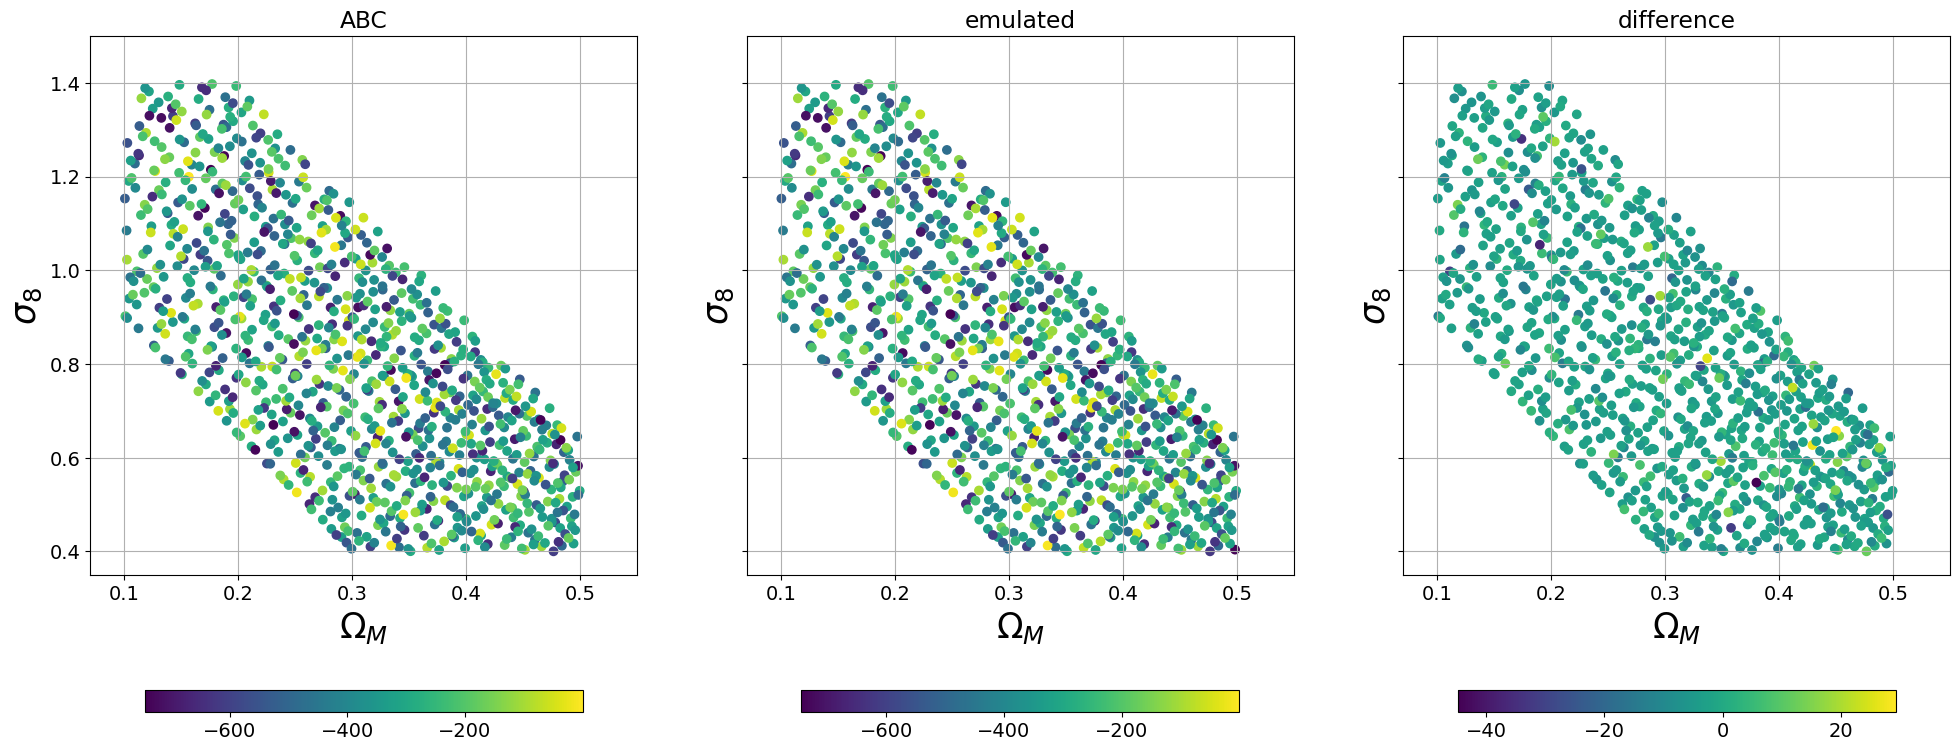

In [21]:
def normalize_Y(Y):
    normalized_prob = Y
    normalized_prob -= np.max(normalized_prob)
    normalized_prob = np.exp(normalized_prob)
    normalized_prob /= np.sum(normalized_prob) 
    
    return normalized_prob

fig, ax = plt.subplots(figsize=(24,10), ncols=3, sharex=True, sharey=True)

# original
original = np.log(normalize_Y(Y_init[:,0]))
im = ax[0].scatter(Om, s8, c=original)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[0].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="ABC")
ax[0].set_xlabel("$\Omega_M$", fontsize=25)
ax[0].set_ylabel("$\sigma_8$", fontsize=25)
ax[0].grid(True)

# emulated
emulated = np.squeeze(np.log(normalize_Y(emu(X_init))))
im = ax[1].scatter(Om, s8, c=emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[1].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="emulated")
ax[1].set_xlabel("$\Omega_M$", fontsize=25)
ax[1].set_ylabel("$\sigma_8$", fontsize=25)
ax[1].grid(True)

# difference
im = ax[2].scatter(Om, s8, c=original - emulated)
fig.colorbar(im, orientation="horizontal", shrink=0.8, aspect=20, pad=0.15)
ax[2].set(xlim=(0.07, 0.55), ylim=(0.35, 1.5), title="difference")
ax[2].set_xlabel("$\Omega_M$", fontsize=25)
ax[2].set_ylabel("$\sigma_8$", fontsize=25)
ax[2].grid(True)


# Run the MCMC

In [22]:
log_posterior = lambda X: prior.log_posterior(X, emu(X), params=params, conf=conf)

In [23]:
# emcee setup
np.random.seed(42)

nwalkers = 1024
ndim = len(params)
p0 = np.random.normal(loc=parameters.get_fiducials(params), scale=1e-3, size=(nwalkers, ndim))
print("Initial values in prior: ", np.all(prior.in_grid_prior(p0, params=params))) 

Initial values in prior:  True


In [24]:
# sample burn in
sampler = EnsembleSampler(nwalkers, ndim, log_posterior, vectorize=True)
state = sampler.run_mcmc(p0, 100)
sampler.reset()
# run the actual chain
sampler.run_mcmc(state, 1000, progress=True); 

100%|██████████| 1000/1000 [01:26<00:00, 11.55it/s]


In [25]:
samples = sampler.get_chain(flat=True)

  0%|          | 0/6 [00:00<?, ?it/s]

  0%|          | 0/6 [00:00<?, ?it/s]

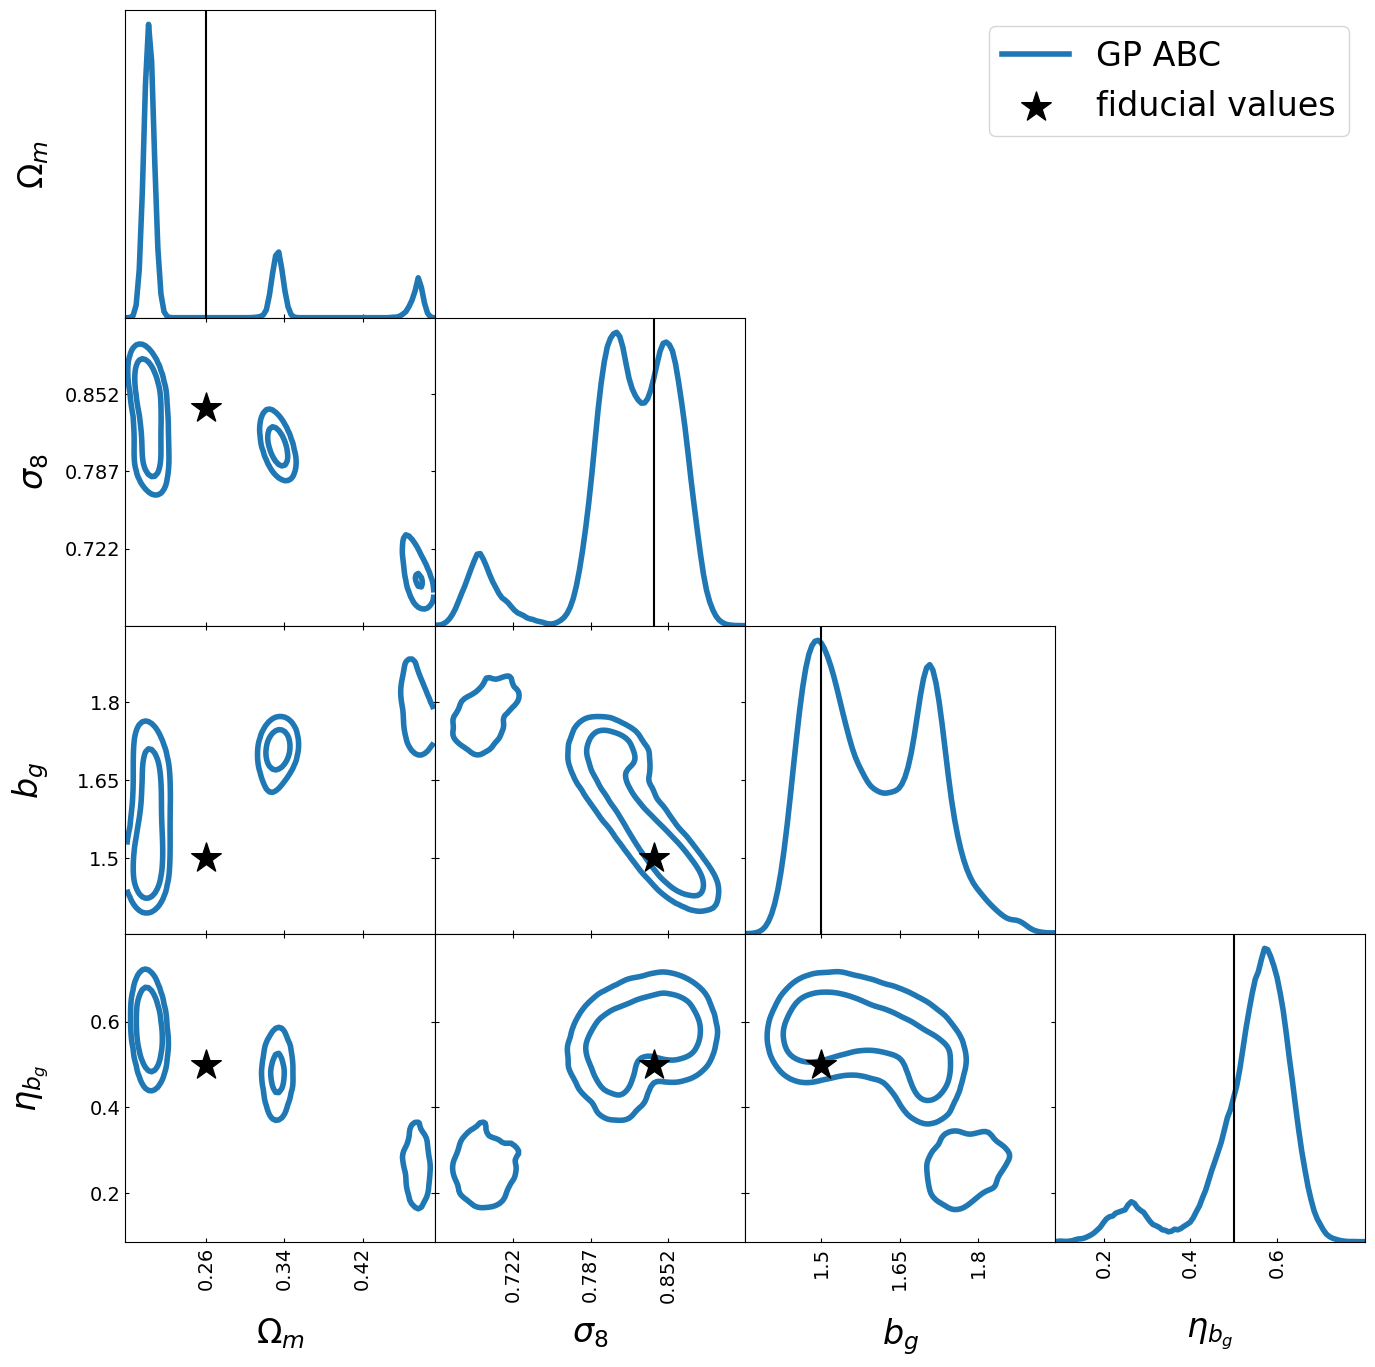

In [26]:
tri = TriangleChain(labels=param_labels, scatter_kwargs={"s": 500, "marker": "*", "zorder": 299})
tri.contour_cl(samples, names=params, label="GP ABC")
tri.scatter(
    fiducial,
    label="fiducial values",
    plot_histograms_1D=False,
    color="k",
    show_legend=True,
    scatter_vline_1D=True,
)
tri.fig.savefig(os.path.join(base_dir, model_dir, f"contours_{n_steps}.png"), bbox_inches="tight", dpi=300)